### **Step 1:** Dataset Selection

In [ ]:
# Step 1: Dataset Selection
import pandas as pd

df = pd.read_csv("credit_risk_dataset.csv")

print("Rows and columns:", df.shape)
print("Number of features:", df.shape[1] - 1)
print("Target variable:", "loan_status")
df.head()

Rows and columns: (32581, 12)
Number of features: 11
Target variable: loan_status


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### **Step 2:** EDA

In [ ]:
# Data types and structure
df.info()

# Summary statistics
df.describe()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

Missing Values:
person_age    

Loan Status Counts:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Loan Status Percentages:
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


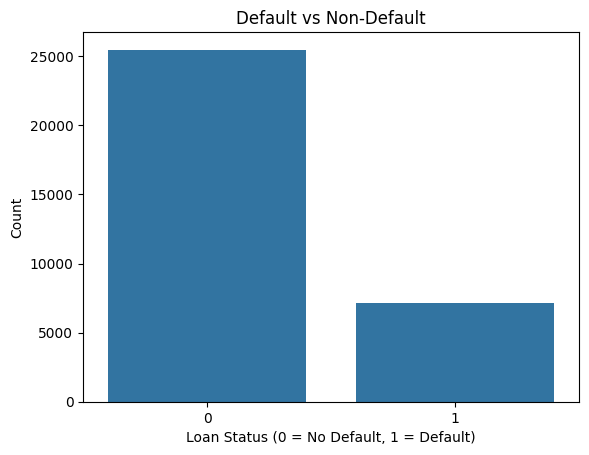

In [ ]:
# TARGET VARIABLE ANALYSIS

import matplotlib.pyplot as plt
import seaborn as sns

# Value counts
print("Loan Status Counts:")
print(df["loan_status"].value_counts())

# Percentages
print("\nLoan Status Percentages:")
print(df["loan_status"].value_counts(normalize=True))

# Plot
sns.countplot(x="loan_status", data=df)
plt.title("Default vs Non-Default")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Count")
plt.show()

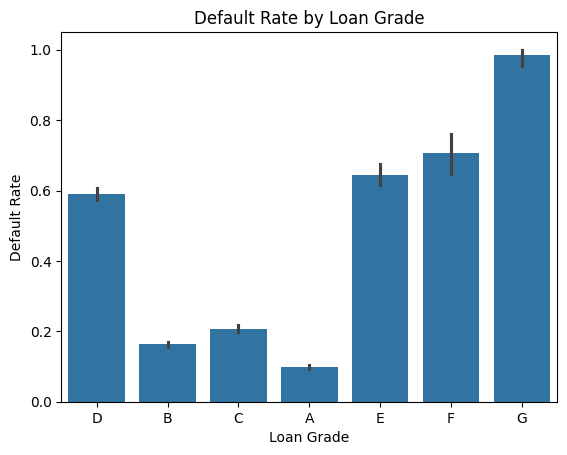

In [ ]:
# Relationships with default

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="loan_grade", y="loan_status", data=df)
plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.show()

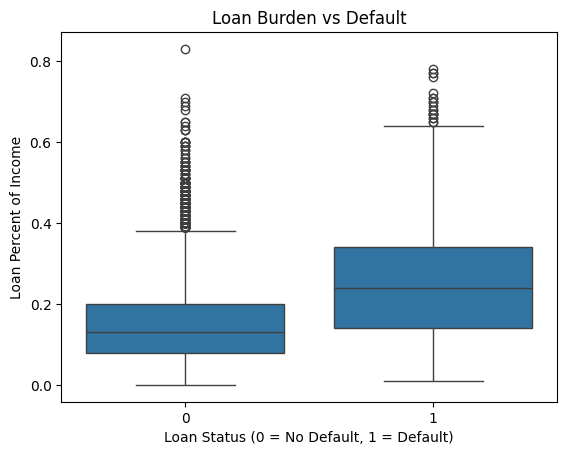

In [ ]:
# Loan burden vs default

sns.boxplot(x="loan_status", y="loan_percent_income", data=df)
plt.title("Loan Burden vs Default")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Loan Percent of Income")
plt.show()

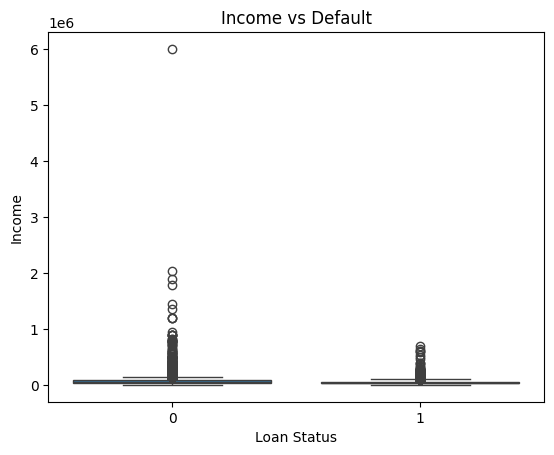

In [ ]:
# Income vs default

sns.boxplot(x="loan_status", y="person_income", data=df)
plt.title("Income vs Default")
plt.xlabel("Loan Status")
plt.ylabel("Income")
plt.show()

### **Step 3:** Data Cleaning and Preprocessing

In [ ]:
# Missing val

df["person_emp_length"] = df["person_emp_length"].fillna(df["person_emp_length"].median())
df["loan_int_rate"] = df["loan_int_rate"].fillna(df["loan_int_rate"].median())

print(df.isnull().sum())

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Outliers

# Cap unrealistic employment length values at 60 years
df.loc[df["person_emp_length"] > 60, "person_emp_length"] = 60

print("Max employment length after capping:")
print(df["person_emp_length"].max())


# Encode categorical var
df_clean = pd.get_dummies(
    df,
    columns=[
        "person_home_ownership",
        "loan_intent",
        "loan_grade",
        "cb_person_default_on_file"
    ],
    drop_first=True
)

print("Shape before encoding:", df.shape)
print("Shape after encoding:", df_clean.shape)
display(df_clean.head())


# Create features and target var

X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)


# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


# Scale features for log regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64
Max employment length after capping:
60.0
Shape before encoding: (32581, 12)
Shape after encoding: (32581, 23)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,60.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


X shape: (32581, 22)
y shape: (32581,)
Training set: (26064, 22)
Testing set: (6517, 22)
Scaling complete.


### **Step 4:** Model Development

In [ ]:
# LOGISTIC REGRESSION

import pandas as pd
import statsmodels.api as sm
import numpy as np

# Use the training data
X_logit = X_train.copy()
y_logit = y_train.copy()

# Convert all True/False dummy variables to 1/0
X_logit = X_logit.astype(float)

# Add intercept
X_logit = sm.add_constant(X_logit)

# Build logistic regression model
logit_model = sm.Logit(y_logit, X_logit)

# Fit model
logit_result = logit_model.fit(maxiter=1000)

# Print full statistical output
print(logit_result.summary())

Optimization terminated successfully.
         Current function value: 0.337874
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:            loan_status   No. Observations:                26064
Model:                          Logit   Df Residuals:                    26041
Method:                           MLE   Df Model:                           22
Date:                Sat, 02 May 2026   Pseudo R-squ.:                  0.3545
Time:                        18:21:25   Log-Likelihood:                -8806.3
converged:                       True   LL-Null:                       -13643.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -3.9609      0.185    -21.373      0.000   

=== BASE RANDOM FOREST: 100 TREES ===
Accuracy: 0.9286481509897192
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.94      0.72      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.93      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517


=== ACCURACY BY NUMBER OF TREES ===


,n_estimators,Accuracy
0,10,0.923891
1,50,0.928648
2,100,0.928648
3,200,0.930029



=== ACCURACY BY MAX DEPTH ===


,max_depth,Accuracy
0,3.0,0.834740
1,5.0,0.896732
2,10.0,0.922510
3,NaN,0.928648



=== TOP 10 FEATURE IMPORTANCES ===


,Feature,Importance
5,loan_percent_income,0.222116
1,person_income,0.149813
4,loan_int_rate,0.121769
3,loan_amnt,0.080086
9,person_home_ownership_RENT,0.078454
2,person_emp_length,0.059375
17,loan_grade_D,0.053093
0,person_age,0.048915
6,cb_person_cred_hist_length,0.038089
8,person_home_ownership_OWN,0.017760


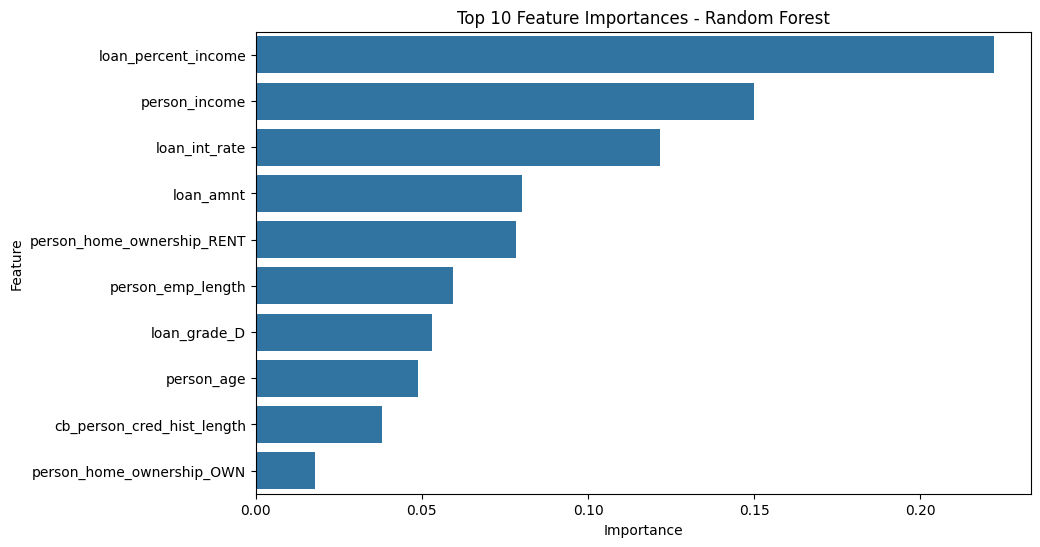

In [ ]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baseline Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== BASE RANDOM FOREST: 100 TREES ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


# Test different number of trees
tree_results = []

for trees in [10, 50, 100, 200]:
    model = RandomForestClassifier(
        n_estimators=trees,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    tree_results.append({
        "n_estimators": trees,
        "Accuracy": accuracy_score(y_test, preds)
    })

tree_results_df = pd.DataFrame(tree_results)

print("\n=== ACCURACY BY NUMBER OF TREES ===")
display(tree_results_df)


# Test different max depths
depth_results = []

for depth in [3, 5, 10, None]:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    depth_results.append({
        "max_depth": depth,
        "Accuracy": accuracy_score(y_test, preds)
    })

depth_results_df = pd.DataFrame(depth_results)

print("\n=== ACCURACY BY MAX DEPTH ===")
display(depth_results_df)


# Feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== TOP 10 FEATURE IMPORTANCES ===")
display(feature_importance.head(10))


# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

=== BASE GRADIENT BOOSTING ===
Accuracy: 0.9176001227558692
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5072
           1       0.92      0.69      0.79      1445

    accuracy                           0.92      6517
   macro avg       0.92      0.84      0.87      6517
weighted avg       0.92      0.92      0.91      6517


=== ACCURACY BY N_ESTIMATORS ===


,n_estimators,Accuracy
0,50,0.906399
1,100,0.917600
2,200,0.926500



=== ACCURACY BY LEARNING RATE ===


,learning_rate,Accuracy
0,0.01,0.853000
1,0.10,0.917600
2,0.20,0.925272



=== TOP 10 FEATURE IMPORTANCES ===


,Feature,Importance
5,loan_percent_income,0.335121
9,person_home_ownership_RENT,0.165625
4,loan_int_rate,0.146383
1,person_income,0.124884
17,loan_grade_D,0.094773
8,person_home_ownership_OWN,0.023874
2,person_emp_length,0.022509
16,loan_grade_C,0.018586
12,loan_intent_MEDICAL,0.012658
11,loan_intent_HOMEIMPROVEMENT,0.010827


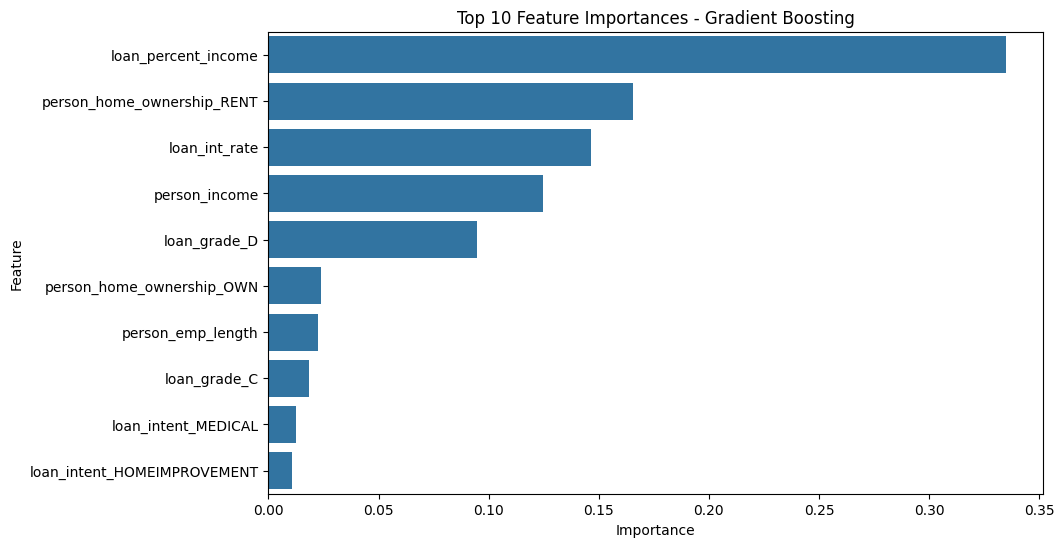

In [ ]:
# GRADIENT BOOSTING

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Baseline Model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("=== BASE GRADIENT BOOSTING ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))



# Test number of estimators
est_results = []

for n in [50, 100, 200]:
    model = GradientBoostingClassifier(
        n_estimators=n,
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    est_results.append({
        "n_estimators": n,
        "Accuracy": accuracy_score(y_test, preds)
    })

est_df = pd.DataFrame(est_results)

print("\n=== ACCURACY BY N_ESTIMATORS ===")
display(est_df)


# Test learning rate
lr_results = []

for lr in [0.01, 0.1, 0.2]:
    model = GradientBoostingClassifier(
        learning_rate=lr,
        n_estimators=100,
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    lr_results.append({
        "learning_rate": lr,
        "Accuracy": accuracy_score(y_test, preds)
    })

lr_df = pd.DataFrame(lr_results)

print("\n=== ACCURACY BY LEARNING RATE ===")
display(lr_df)


# Feature importance
gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n=== TOP 10 FEATURE IMPORTANCES ===")
display(gb_importance.head(10))


# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=gb_importance.head(10)
)
plt.title("Top 10 Feature Importances - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

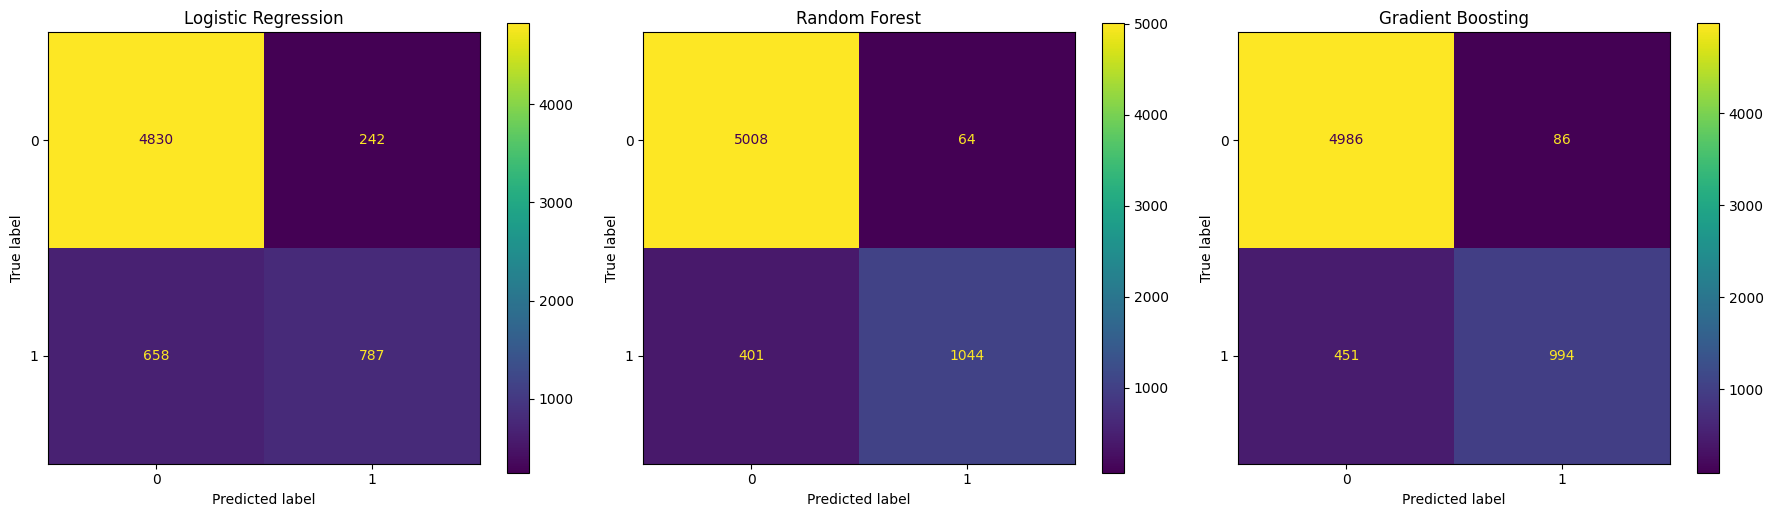

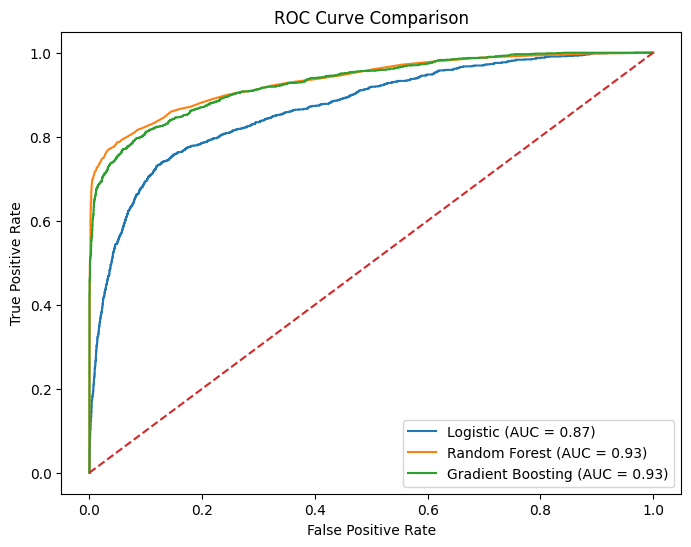

In [ ]:
# FINAL MODEL COMPARISON

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Confusion matrices

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log).plot(ax=axes[0])
axes[0].set_title("Logistic Regression")

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot(ax=axes[1])
axes[1].set_title("Random Forest")

# Gradient Boosting
cm_gb = confusion_matrix(y_test, y_pred_gb)
ConfusionMatrixDisplay(cm_gb).plot(ax=axes[2])
axes[2].set_title("Gradient Boosting")

plt.tight_layout()
plt.show()


# ROC Curves

# Probabilities
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# AUC scores
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [ ]:
# HYPERPARAMETER TUNING FOR RANDOM FOREST

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Set up parameter options to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Create grid search
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

# Fit grid search on training data
rf_grid.fit(X_train, y_train)

# Save best model
best_rf = rf_grid.best_estimator_

print("Best Parameters:")
print(rf_grid.best_params_)

# Predict using tuned model
y_pred_best_rf = best_rf.predict(X_test)

# Evaluate tuned model
print("\nTUNED RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall:", recall_score(y_test, y_pred_best_rf))
print("F1 Score:", f1_score(y_test, y_pred_best_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

print("=== ORIGINAL RANDOM FOREST ===")
print("Accuracy:", rf_accuracy)
print("Recall:", rf_recall)

print("\n=== TUNED RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Recall:", recall_score(y_test, y_pred_best_rf))

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

TUNED RANDOM FOREST RESULTS
Accuracy: 0.9300291545189504
Precision: 0.9483227561196736
Recall: 0.7238754325259515
F1 Score: 0.8210361067503925

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5072
           1       0.95      0.72      0.82      1445

    accuracy                           0.93      6517
   macro avg       0.94      0.86      0.89      6517
weighted avg       0.93      0.93      0.93      6517

=== ORIGINAL RANDOM FOREST ===
Accuracy: 0.9286481509897192
Recall: 0.7224913494809688

=== TUNED RANDOM FOREST ===
Accuracy: 0.9300291545189504
Recall: 0.7238754325259515
